In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

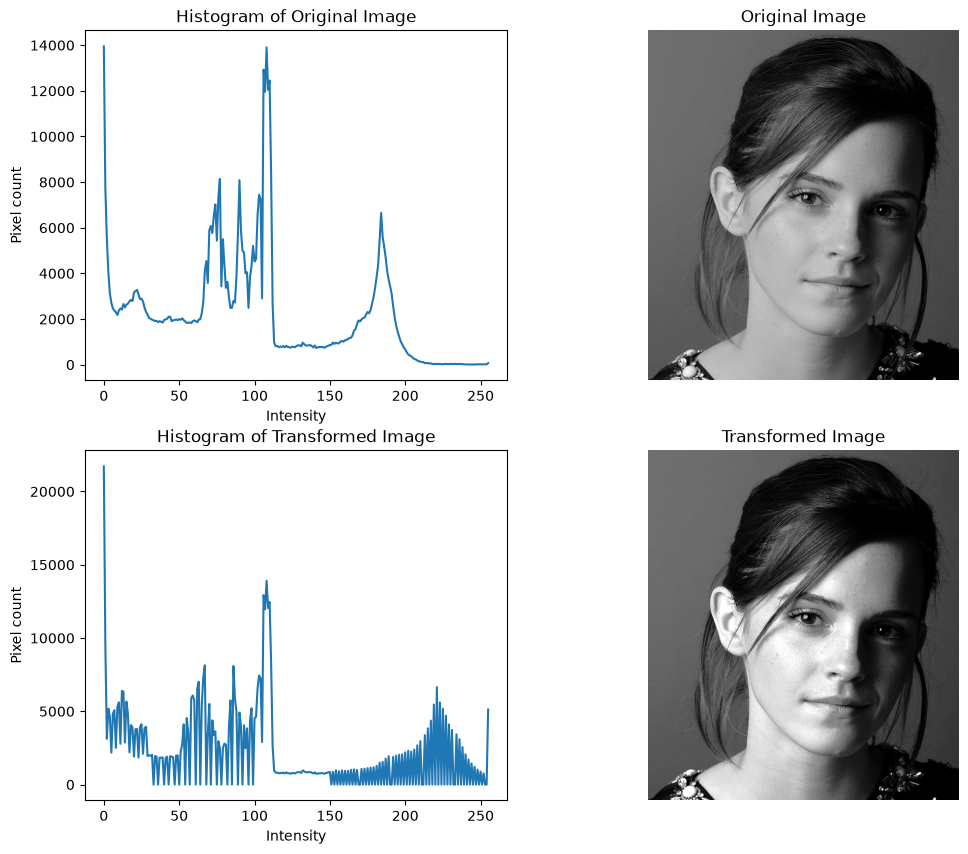

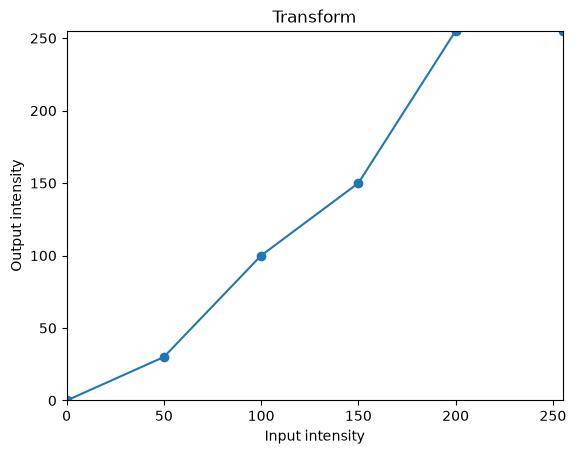

In [26]:
im = cv.imread("images/q1.jpeg", cv.IMREAD_GRAYSCALE)

hist = cv.calcHist([im], [0], None, [256], [0,256])

xp = [0, 50, 100, 150, 200, 255]
fp = [0, 30, 100, 150, 255, 255]

lut = np.interp(np.arange(256), xp, fp).astype(np.uint8)

transformed_image = cv.LUT(im, lut)
tr_hist = cv.calcHist([transformed_image], [0], None, [256], [0,256])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].plot(hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Histogram of Original Image")

axes[0][1].imshow(im, cmap='gray')
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[1][0].plot(tr_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("Histogram of Transformed Image")

axes[1][1].imshow(transformed_image, cmap='gray')
axes[1][1].axis('off')
axes[1][1].set_title("Transformed Image")

plt.show()

plt.plot(xp, fp, 'o-')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Transform")

plt.show()

In [ ]:
from ipywidgets import interact, IntSlider

im = cv.imread("images/q1.jpeg", cv.IMREAD_GRAYSCALE)

def show_transform(y0, y50, y100, y150, y200, y255):
    xp = [0, 50, 100, 150, 200, 255]
    fp = [y0, y50, y100, y150, y200, y255]

    lut = np.interp(np.arange(256), xp, fp).astype(np.uint8)
    transformed_image = cv.LUT(im, lut)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].plot(xp, fp, 'o-')
    axes[0].set_xlim(0, 255)
    axes[0].set_ylim(0, 255)
    axes[0].set_xlabel("Input intensity")
    axes[0].set_ylabel("Output intensity")
    axes[0].set_title("Transform")

    axes[1].imshow(im, cmap='gray')
    axes[1].axis('off')
    axes[1].set_title("Original Image")

    axes[2].imshow(transformed_image, cmap='gray')
    axes[2].axis('off')
    axes[2].set_title("Transformed Image")

    plt.show()

interact(show_transform,
         y0=IntSlider(min=0, max=255, value=0),
         y50=IntSlider(min=0, max=255, value=0),
         y100=IntSlider(min=0, max=255, value=0),
         y150=IntSlider(min=0, max=255, value=0),
         y200=IntSlider(min=0, max=255, value=255),
         y255=IntSlider(min=0, max=255, value=255));

interactive(children=(IntSlider(value=0, description='y0', max=255), IntSlider(value=0, description='y50', max…